this code is for pairwise RMSD analysis between two simulations (V7 & V12) - adaptable

In [ ]:
!pip install MDAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 1.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 50.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 62.8 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.4 MB/s eta 0:00:00


In [ ]:
!pip install MDAnalysisTests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 13.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.8/533.8 kB 30.5 MB/s eta 0:00:00
  Created wheel for MDAnalysisTests: filename=mdanalysistests-2.10.0-py3-none-any.whl size=58343066 sha256=7f143c5e5e0abf37d05fdef6da87eed2f22e7575d00241df1362f2206d699d92
  Stored in directory: /root/.cache/pip/wheels/48/cc/44/560d1d4b77f1a4b0a8cb5be5d12001c911d7e6190511d7e571
Successfully built MDAnalysisTests


In [5]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD, CRD, DCD2
from MDAnalysis.analysis import diffusionmap, align, rms
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#from google.colab import drive
# drive.mount('/content/drive')

rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
os.chdir(rootdir)

In [7]:
V7 = mda.Universe("./simulations_1HSI_APO_MP/V7/V7.gro", "./simulations_1HSI_APO_MP/V7/md_V7.xtc")
V12 = mda.Universe("./simulations_1HSI_APO_DP/V12/V12.gro", "./simulations_1HSI_APO_DP/V12/md_V12.xtc")


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


In [8]:
prmsd = np.zeros((len(V7.trajectory),  # y-axis
                  len(V12.trajectory)))  # x-axis

In [ ]:
#prmsd.shape

(1001, 1001)

In [11]:
for i, frame_open in enumerate(V12.trajectory):
    r = rms.RMSD(V7, V12, select='name CA',
                 ref_frame=i).run()
    prmsd[i] = r.results.rmsd[:, -1]  # select 3rd column with RMSD values

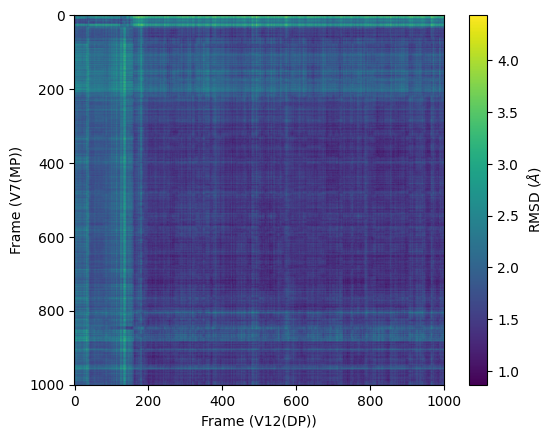

In [12]:
plt.imshow(prmsd, cmap='viridis')
plt.xlabel('Frame (V12(DP))')
plt.ylabel('Frame (V7(MP))')
plt.colorbar(label=r'RMSD ($\AA$)')

In [14]:
df = pd.DataFrame(prmsd)

In [49]:
min_row, min_col = df.stack().idxmin()
min_RMSD = df.iloc[min_row, min_col]

max_row, max_col = df.stack().idxmax()
max_RMSD = df.iloc[max_row, max_col]

print(f"Minimum RMSD: {min_RMSD:.2f} Å at (V7 frame: {min_row}, V12 frame: {min_col})")
print(f"Maximum RMSD: {max_RMSD:.2f} Å at (V7 frame: {max_row}, V12 frame: {max_col})")

Minimum RMSD: 0.87 Å at (V7 frame: 615, V12 frame: 477)
Maximum RMSD: 4.44 Å at (V7 frame: 4, V12 frame: 493)


In [52]:
df1 = df.iloc[190:200,30:40]
df1.stack().idxmin()
display(df1)
print(f"Average RMSD for transition region in both simulations: {df1.values.mean():.2f} Å")
print(f"Minimum RMSD in transition region: {df1.values.min():.2f} Å, at (V7 frame: {df1.stack().idxmin()[0]}, V12 frame: {df1.stack().idxmin()[1]})")
print(f"Maximum RMSD in transition region: {df1.values.max():.2f} Å, at (V7 frame: {df1.stack().idxmax()[0]}, V12 frame: {df1.stack().idxmax()[1]})")

,30,31,32,33,34,35,36,37,38,39
190,2.454272,2.329318,2.383294,2.288823,3.038994,2.646226,2.509670,2.470251,3.112461,2.381532
191,2.655378,2.539339,2.532466,2.422170,3.137940,2.913463,2.668737,2.739963,3.150094,2.586502
192,2.520004,2.421595,2.544353,2.446715,3.093385,2.735986,2.554717,2.529393,3.108205,2.345827
193,2.423585,2.330277,2.414744,2.301088,3.058812,2.728460,2.519960,2.572821,2.956259,2.456537
194,2.512636,2.407214,2.453320,2.345493,3.035363,2.680794,2.486853,2.555488,3.017935,2.347499
195,2.219412,2.099191,2.112680,2.103295,2.718807,2.416338,2.328969,2.409953,2.928133,2.381344
196,2.372721,2.182704,2.204392,2.153187,2.816741,2.667362,2.512339,2.598139,3.057953,2.595282
197,2.337647,2.202470,2.205419,2.127288,2.752693,2.486047,2.410561,2.507390,2.900481,2.395685
198,2.542429,2.333142,2.292882,2.164441,2.950723,2.765854,2.574037,2.729997,3.145914,2.614150
199,2.454643,2.308483,2.388640,2.301976,3.011834,2.710135,2.511636,2.572867,2.943949,2.418556


Average RMSD for transition region in both simulations: 2.56 Å
Minimum RMSD in transition region: 2.10 Å, at (V7 frame: 195, V12 frame: 31)
Maximum RMSD in transition region: 3.15 Å, at (V7 frame: 191, V12 frame: 38)


In [37]:
df2 = df.iloc[30:40,190:200]
df2.stack().idxmin()
display(df2)

,190,191,192,193,194,195,196,197,198,199
30,2.446014,2.310687,2.438539,2.238466,2.274021,2.302219,2.375262,2.524798,2.257979,2.405843
31,2.289778,2.210578,2.320202,2.023195,2.135739,2.188344,2.230421,2.457949,2.070581,2.271788
32,2.323264,2.037902,2.219803,1.904724,1.977090,1.965551,2.178353,2.378846,1.924286,2.111195
33,2.133138,1.899580,2.141851,1.841571,2.014928,1.902848,1.912739,2.170446,1.802910,1.963435
34,1.962960,1.781827,2.013328,1.696890,1.944692,1.926864,1.909227,2.061855,1.820550,1.888722
35,1.969811,1.841547,2.067004,1.791386,2.005300,1.852712,1.887759,2.103038,1.812336,1.949936
36,1.547457,1.811491,1.857077,1.521584,1.823638,1.713367,1.537471,1.694257,1.695324,1.705126
37,1.647233,1.622464,1.701679,1.566107,1.665672,1.601168,1.704757,1.864453,1.575323,1.652711
38,1.671063,1.627658,1.651785,1.673921,1.677797,1.725387,1.844147,1.889295,1.653196,1.732774
39,1.730027,1.711758,1.779813,1.701112,1.746299,1.767566,1.823904,1.738260,1.541812,1.632185
